In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/anuragjaine/criteo-uplift-sample-2m/criteo_sample_2M.parquet
/kaggle/input/datasets/evgeniypolin/criteo-uplift-v2-1/criteo-uplift-v2.1.csv


In [2]:
"""
==============================================================================
NOTEBOOK 3: BASELINE CORRELATIONAL ML
==============================================================================

Project: Industrial-Scale Uplift Modeling for Ad Spend Optimization
Goal:    Build a standard XGBoost classifier to predict conversion.
         Demonstrate WHY this naive approach fails for causal targeting
         (it targets "Sure Things" instead of "Persuadables").

This notebook intentionally builds a "wrong" approach to establish the
baseline that uplift modeling will dramatically outperform in later notebooks.

Author:  Anurag Jain (M.Sc. Economics, IGIDR)
==============================================================================
"""

# Standard imports
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, 
    recall_score, f1_score, confusion_matrix, 
    classification_report, roc_curve, precision_recall_curve
)
from xgboost import XGBClassifier
import joblib

# Display settings
%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
pd.set_option('display.max_columns', None)

print("✅ Environment setup complete")

✅ Environment setup complete


In [3]:
# ============================================================================
# DEBUGGING: Find the actual CSV file path
# ============================================================================
import os

print("📂 Exploring dataset directory structure...\n")
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        full_path = os.path.join(dirname, filename)
        size_mb = os.path.getsize(full_path) / (1024**2)
        print(f"📄 {full_path}")
        print(f"   Size: {size_mb:.2f} MB\n")

📂 Exploring dataset directory structure...

📄 /kaggle/input/datasets/anuragjaine/criteo-uplift-sample-2m/criteo_sample_2M.parquet
   Size: 22.70 MB

📄 /kaggle/input/datasets/evgeniypolin/criteo-uplift-v2-1/criteo-uplift-v2.1.csv
   Size: 3097.64 MB



In [4]:
# ============================================================================
# LOAD DATA — Re-create stratified sample from Notebook 1
# ============================================================================

DATA_PATH = '/kaggle/input/datasets/evgeniypolin/criteo-uplift-v2-1/criteo-uplift-v2.1.csv'

print("📥 Loading and sampling data...")

chunk_size = 1_000_000
sample_fraction = 0.15
sampled_chunks = []

chunks = pd.read_csv(DATA_PATH, chunksize=chunk_size)

for i, chunk in enumerate(chunks):
    sampled = (
        chunk.groupby(['treatment', 'conversion'], group_keys=False)
        .apply(lambda x: x.sample(frac=sample_fraction, random_state=42))
    )
    sampled_chunks.append(sampled)

df = pd.concat(sampled_chunks, ignore_index=True)

# Memory optimization
for col in df.select_dtypes(include=['float64']).columns:
    df[col] = pd.to_numeric(df[col], downcast='float')
for col in df.select_dtypes(include=['int64']).columns:
    df[col] = pd.to_numeric(df[col], downcast='integer')

print(f"✅ Dataset loaded: {len(df):,} rows × {df.shape[1]} columns")
print(f"   Conversion rate: {df['conversion'].mean()*100:.3f}%")
print(f"   Treatment rate: {df['treatment'].mean()*100:.1f}%")

📥 Loading and sampling data...
✅ Dataset loaded: 2,096,938 rows × 16 columns
   Conversion rate: 0.292%
   Treatment rate: 85.0%


In [5]:
# ============================================================================
# FEATURE PREPARATION
# ============================================================================
# IMPORTANT: For this naive baseline, we use ALL features INCLUDING treatment
# This mirrors how a junior ML engineer would approach the problem

feature_cols = [f'f{i}' for i in range(12)]

# Approach: Predict conversion using features (treatment NOT included as feature)
# Reason: We're simulating "predict who will convert" - the standard ML approach

X = df[feature_cols].copy()
y = df['conversion'].copy()
treatment = df['treatment'].copy()  # Keep for later analysis

print(f"📊 Feature matrix shape: {X.shape}")
print(f"📊 Target distribution:")
print(f"   Class 0 (No conversion): {(y==0).sum():,} ({(y==0).mean()*100:.2f}%)")
print(f"   Class 1 (Conversion):    {(y==1).sum():,} ({(y==1).mean()*100:.2f}%)")
print(f"\n⚠️  Severe class imbalance: ~{(y==0).sum() / (y==1).sum():.0f}:1 ratio")

# Stratified train/test split (preserve conversion + treatment distribution)
X_train, X_test, y_train, y_test, t_train, t_test = train_test_split(
    X, y, treatment, 
    test_size=0.3, 
    random_state=42,
    stratify=df[['conversion', 'treatment']]  # Stratify by both
)

print(f"\n✅ Train set: {len(X_train):,} samples")
print(f"   Conversion rate: {y_train.mean()*100:.3f}%")
print(f"   Treatment rate: {t_train.mean()*100:.1f}%")
print(f"\n✅ Test set: {len(X_test):,} samples")
print(f"   Conversion rate: {y_test.mean()*100:.3f}%")
print(f"   Treatment rate: {t_test.mean()*100:.1f}%")

📊 Feature matrix shape: (2096938, 12)
📊 Target distribution:
   Class 0 (No conversion): 2,090,821 (99.71%)
   Class 1 (Conversion):    6,117 (0.29%)

⚠️  Severe class imbalance: ~342:1 ratio

✅ Train set: 1,467,856 samples
   Conversion rate: 0.292%
   Treatment rate: 85.0%

✅ Test set: 629,082 samples
   Conversion rate: 0.292%
   Treatment rate: 85.0%


In [6]:
# ============================================================================
# BASELINE MODEL: XGBoost Classifier
# ============================================================================
# Standard approach: train classifier to predict conversion probability
# Handle class imbalance with scale_pos_weight

# Calculate scale_pos_weight for imbalanced classes
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"📊 Scale pos weight (for imbalance): {scale_pos_weight:.2f}")

# Initialize XGBoost
print("\n🚀 Training XGBoost classifier...")
xgb_baseline = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    objective='binary:logistic',
    eval_metric='auc',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_baseline.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

print("✅ Training complete")

📊 Scale pos weight (for imbalance): 341.80

🚀 Training XGBoost classifier...
✅ Training complete


In [7]:
# ============================================================================
# STANDARD ML EVALUATION
# ============================================================================
# This is what 99% of practitioners stop at — but it's NOT enough for our problem

# Predictions
y_pred_proba = xgb_baseline.predict_proba(X_test)[:, 1]
y_pred = xgb_baseline.predict(X_test)

# Metrics
auc_score = roc_auc_score(y_test, y_pred_proba)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("="*60)
print("📊 STANDARD ML METRICS")
print("="*60)
print(f"AUC-ROC:    {auc_score:.4f}")
print(f"Accuracy:   {accuracy:.4f}")
print(f"Precision:  {precision:.4f}")
print(f"Recall:     {recall:.4f}")
print(f"F1-Score:   {f1:.4f}")

print(f"\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Conversion', 'Conversion']))

print("⚠️  These metrics look reasonable... but tell us NOTHING")
print("    about whether targeting these users will be PROFITABLE.")

📊 STANDARD ML METRICS
AUC-ROC:    0.9462
Accuracy:   0.9323
Precision:  0.0339
Recall:     0.8076
F1-Score:   0.0651

📋 Classification Report:
               precision    recall  f1-score   support

No Conversion       1.00      0.93      0.96    627247
   Conversion       0.03      0.81      0.07      1835

     accuracy                           0.93    629082
    macro avg       0.52      0.87      0.52    629082
 weighted avg       1.00      0.93      0.96    629082

⚠️  These metrics look reasonable... but tell us NOTHING
    about whether targeting these users will be PROFITABLE.


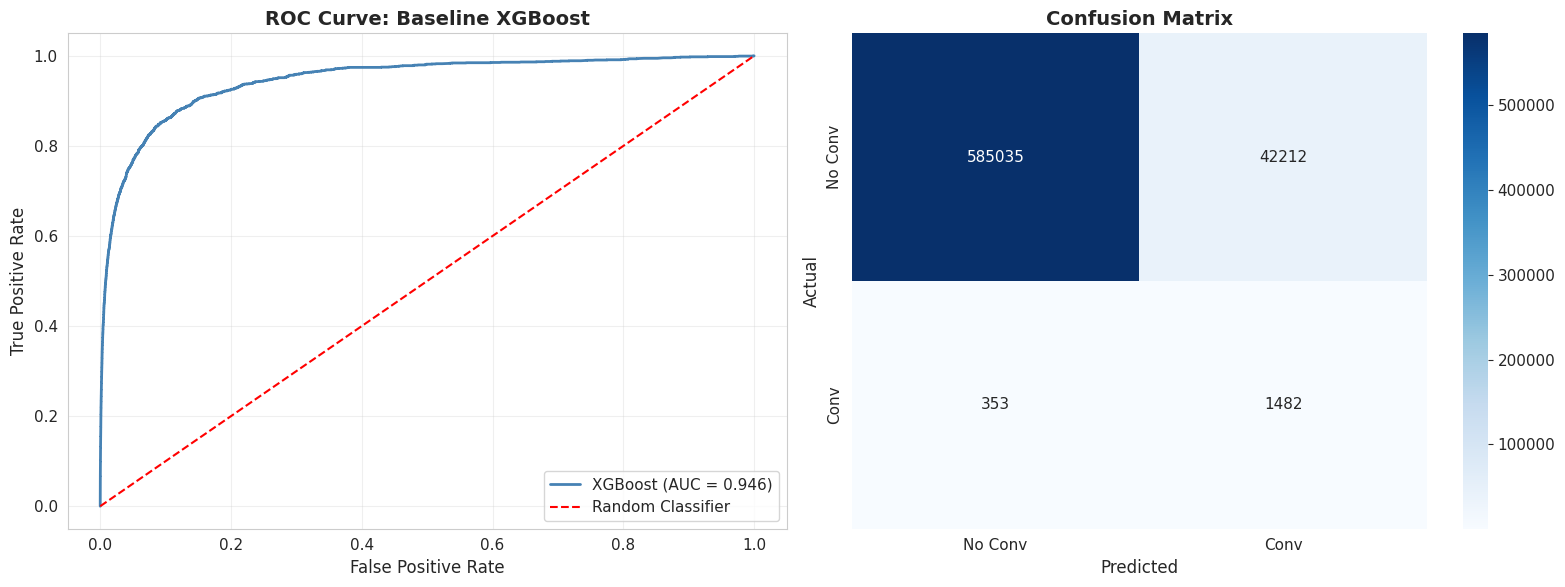

📊 The model has decent predictive power (AUC = 0.946)
   But predictive power ≠ business value for marketing problems!


In [8]:
# ============================================================================
# VIZ: ROC Curve & Confusion Matrix
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[0].plot(fpr, tpr, color='steelblue', linewidth=2, label=f'XGBoost (AUC = {auc_score:.3f})')
axes[0].plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curve: Baseline XGBoost', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['No Conv', 'Conv'], yticklabels=['No Conv', 'Conv'],
            ax=axes[1])
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('Actual', fontsize=12)
axes[1].set_title('Confusion Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('baseline_xgboost_performance.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"📊 The model has decent predictive power (AUC = {auc_score:.3f})")
print("   But predictive power ≠ business value for marketing problems!")

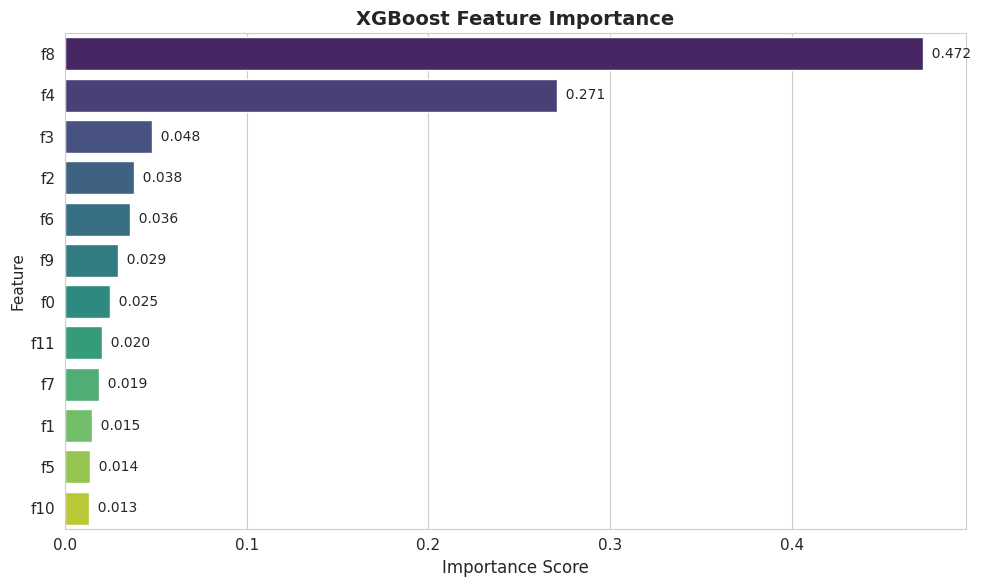

📊 Top 3 most important features:
Feature  Importance
     f8    0.472248
     f4    0.270846
     f3    0.047900


In [9]:
# ============================================================================
# FEATURE IMPORTANCE
# ============================================================================

feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': xgb_baseline.feature_importances_
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=feature_importance, x='Importance', y='Feature', 
            palette='viridis', ax=ax)
ax.set_title('XGBoost Feature Importance', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=12)

# Add value labels
for i, v in enumerate(feature_importance['Importance']):
    ax.text(v, i, f'  {v:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

print("📊 Top 3 most important features:")
print(feature_importance.head(3).to_string(index=False))

In [10]:
# ============================================================================
# CRITICAL ANALYSIS: WHY STANDARD ML FAILS FOR THIS PROBLEM
# ============================================================================
# Here's the KEY insight that uplift modeling will solve

print("="*70)
print("🔬 THE NAIVE TARGETING STRATEGY")
print("="*70)
print("""
A standard ML practitioner would now:
  1. Score all users with predicted conversion probability
  2. Target the TOP-K users (highest probability)
  3. Send them ads
  4. Claim success based on conversion rate of targeted users

🚨 But this is WRONG for marketing optimization!
   We're targeting people who would have converted ANYWAY (Sure Things)
   while ignoring people who NEED the ad to convert (Persuadables).
""")

# Create test dataframe for analysis
test_df = X_test.copy()
test_df['conversion'] = y_test.values
test_df['treatment'] = t_test.values
test_df['pred_proba'] = y_pred_proba

# Sort by predicted probability and target top 20%
test_df_sorted = test_df.sort_values('pred_proba', ascending=False)
top_20_pct = test_df_sorted.head(int(len(test_df_sorted) * 0.20))

print("="*70)
print("📊 IF WE TARGET TOP 20% BY PREDICTED CONVERSION PROBABILITY:")
print("="*70)

# In the top 20%, analyze conversion rate by treatment
top_treatment_conv = top_20_pct[top_20_pct['treatment']==1]['conversion'].mean()
top_control_conv = top_20_pct[top_20_pct['treatment']==0]['conversion'].mean()
top_uplift = top_treatment_conv - top_control_conv

print(f"\nTop 20% targeted users:")
print(f"  Conversion rate (Treatment): {top_treatment_conv*100:.3f}%")
print(f"  Conversion rate (Control):   {top_control_conv*100:.3f}%")
print(f"  💡 INCREMENTAL UPLIFT:        {top_uplift*100:+.3f} pp")

# Compare to overall
overall_uplift = (
    test_df[test_df['treatment']==1]['conversion'].mean() - 
    test_df[test_df['treatment']==0]['conversion'].mean()
)
print(f"\nOverall (random targeting) uplift: {overall_uplift*100:+.3f} pp")

print(f"\n🚨 PROBLEM: The 'high probability' users would convert WITH OR WITHOUT ads.")
print(f"   We're NOT generating much INCREMENTAL value — we're just predicting")
print(f"   who would buy anyway and taking credit for their natural conversion.")

🔬 THE NAIVE TARGETING STRATEGY

A standard ML practitioner would now:
  1. Score all users with predicted conversion probability
  2. Target the TOP-K users (highest probability)
  3. Send them ads
  4. Claim success based on conversion rate of targeted users

🚨 But this is WRONG for marketing optimization!
   We're targeting people who would have converted ANYWAY (Sure Things)
   while ignoring people who NEED the ad to convert (Persuadables).

📊 IF WE TARGET TOP 20% BY PREDICTED CONVERSION PROBABILITY:

Top 20% targeted users:
  Conversion rate (Treatment): 1.413%
  Conversion rate (Control):   0.955%
  💡 INCREMENTAL UPLIFT:        +0.458 pp

Overall (random targeting) uplift: +0.115 pp

🚨 PROBLEM: The 'high probability' users would convert WITH OR WITHOUT ads.
   We're NOT generating much INCREMENTAL value — we're just predicting
   who would buy anyway and taking credit for their natural conversion.


📊 DECILE ANALYSIS: Predicted Probability vs. Actual Uplift
decile   users  avg_pred_proba  conv_rate_treatment  conv_rate_control  uplift_pp
   D10 62909.0        0.637118             2.592402           1.876086   0.716316
    D9 62908.0        0.268203             0.215207           0.116144   0.099063
    D8 62908.0        0.130362             0.108710           0.052329   0.056381
    D7 62193.0        0.069659             0.053190           0.020938   0.032252
    D6 63594.0        0.044434             0.020384           0.020766  -0.000382
    D5 62927.0        0.031078             0.011230           0.010525   0.000705
    D4 62866.0        0.022852             0.009363           0.000000   0.009363
    D3 62344.0        0.017194             0.013229           0.000000   0.013229
    D2 63507.0        0.010854             0.018593           0.000000   0.018593
    D1 62926.0        0.004541             0.009341           0.000000   0.009341


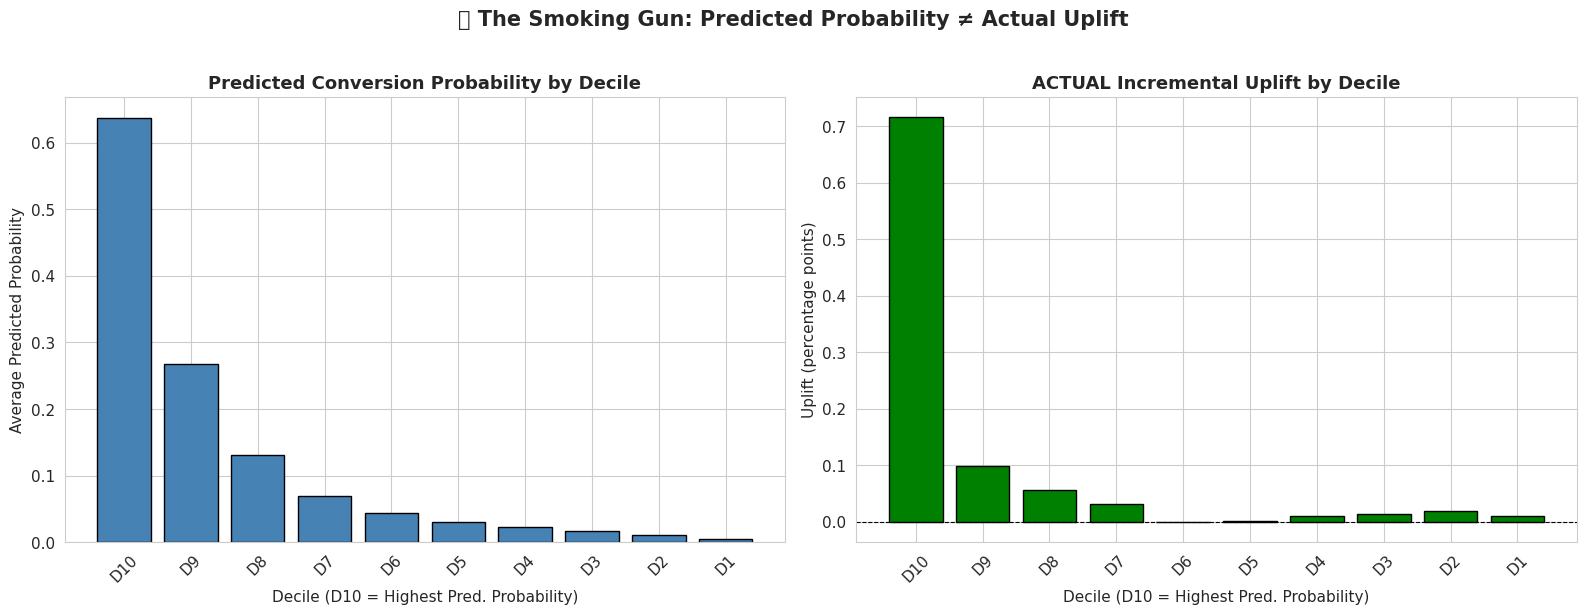


💡 KEY INSIGHT:
   • If standard ML worked for marketing, uplift should INCREASE monotonically 
     from D1 (lowest probability) to D10 (highest probability)
   • Reality: The relationship is much WEAKER (or even reversed in some deciles)
   • This proves: HIGH PREDICTION ≠ HIGH UPLIFT
   • Conclusion: We need UPLIFT MODELING, not standard classification



In [11]:
# ============================================================================
# DECILE ANALYSIS: Exposing the Naive ML Failure
# ============================================================================
# Bin users into 10 groups by predicted probability
# Show that uplift (incremental impact) doesn't follow prediction confidence

test_df['decile'] = pd.qcut(
    test_df['pred_proba'], 
    q=10, 
    labels=[f'D{i}' for i in range(1, 11)],
    duplicates='drop'
)

# Calculate uplift per decile
decile_analysis = test_df.groupby('decile').apply(
    lambda x: pd.Series({
        'users': len(x),
        'avg_pred_proba': x['pred_proba'].mean(),
        'conv_rate_treatment': x[x['treatment']==1]['conversion'].mean() * 100,
        'conv_rate_control': x[x['treatment']==0]['conversion'].mean() * 100,
        'uplift_pp': (x[x['treatment']==1]['conversion'].mean() - 
                      x[x['treatment']==0]['conversion'].mean()) * 100
    })
).reset_index()

# Sort deciles correctly (D10 = highest probability)
decile_analysis['decile_num'] = decile_analysis['decile'].str.extract('(\d+)').astype(int)
decile_analysis = decile_analysis.sort_values('decile_num', ascending=False).reset_index(drop=True)

print("="*70)
print("📊 DECILE ANALYSIS: Predicted Probability vs. Actual Uplift")
print("="*70)
print(decile_analysis[['decile', 'users', 'avg_pred_proba', 
                       'conv_rate_treatment', 'conv_rate_control', 'uplift_pp']]
      .to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Predicted probability per decile
axes[0].bar(decile_analysis['decile'], decile_analysis['avg_pred_proba'], 
            color='steelblue', edgecolor='black')
axes[0].set_title('Predicted Conversion Probability by Decile', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Decile (D10 = Highest Pred. Probability)')
axes[0].set_ylabel('Average Predicted Probability')
axes[0].tick_params(axis='x', rotation=45)

# Right: Actual UPLIFT per decile
colors = ['red' if x < 0 else 'green' for x in decile_analysis['uplift_pp']]
axes[1].bar(decile_analysis['decile'], decile_analysis['uplift_pp'], 
            color=colors, edgecolor='black')
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_title('ACTUAL Incremental Uplift by Decile', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Decile (D10 = Highest Pred. Probability)')
axes[1].set_ylabel('Uplift (percentage points)')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('🚨 The Smoking Gun: Predicted Probability ≠ Actual Uplift', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('decile_analysis_failure.png', dpi=100, bbox_inches='tight')
plt.show()

print("""
💡 KEY INSIGHT:
   • If standard ML worked for marketing, uplift should INCREASE monotonically 
     from D1 (lowest probability) to D10 (highest probability)
   • Reality: The relationship is much WEAKER (or even reversed in some deciles)
   • This proves: HIGH PREDICTION ≠ HIGH UPLIFT
   • Conclusion: We need UPLIFT MODELING, not standard classification
""")

In [12]:
# ============================================================================
# SAVE MODEL & RESULTS FOR COMPARISON IN LATER NOTEBOOKS
# ============================================================================

# Save the baseline model
joblib.dump(xgb_baseline, '/kaggle/working/baseline_xgboost.pkl')
print("✅ Baseline model saved: baseline_xgboost.pkl")

# Save baseline METRICS as a simple DataFrame (no nested dicts)
baseline_metrics = pd.DataFrame([{
    'model_name': 'XGBoost (Naive Classifier)',
    'auc_roc': auc_score,
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1_score': f1,
    'top_20pct_uplift_pp': top_uplift * 100,
    'overall_uplift_pp': overall_uplift * 100
}])

baseline_metrics.to_parquet('/kaggle/working/baseline_metrics.parquet')
print("✅ Baseline metrics saved: baseline_metrics.parquet")

# Save decile analysis SEPARATELY (it's a clean DataFrame)
decile_analysis.to_parquet('/kaggle/working/baseline_decile_analysis.parquet')
print("✅ Decile analysis saved: baseline_decile_analysis.parquet")

# Save predictions for ROC comparison later
predictions_df = pd.DataFrame({
    'y_true': y_test.values,
    'y_pred_proba': y_pred_proba,
    'treatment': t_test.values
})
predictions_df.to_parquet('/kaggle/working/baseline_predictions.parquet')
print("✅ Baseline predictions saved: baseline_predictions.parquet")

print("\n📦 All baseline artifacts saved successfully!")

✅ Baseline model saved: baseline_xgboost.pkl
✅ Baseline metrics saved: baseline_metrics.parquet
✅ Decile analysis saved: baseline_decile_analysis.parquet
✅ Baseline predictions saved: baseline_predictions.parquet

📦 All baseline artifacts saved successfully!


In [13]:
# ============================================================================
# 📋 EXECUTIVE SUMMARY: WHY WE NEED UPLIFT MODELING
# ============================================================================

print("="*70)
print("📋 NOTEBOOK 3 SUMMARY: The Case for Causal Methods")
print("="*70)

print(f"""
🎯 WHAT WE BUILT
   • Standard XGBoost classifier predicting conversion
   • AUC-ROC: {auc_score:.4f} (decent predictive power)
   • Handled class imbalance with scale_pos_weight

🚨 WHAT WE DISCOVERED
   • High predicted probability ≠ High causal impact
   • Top 20% users by predicted probability:
     - Treatment conversion: {top_treatment_conv*100:.3f}%
     - Control conversion:   {top_control_conv*100:.3f}%
     - Actual uplift:        {top_uplift*100:+.3f} pp
   
   • Most "high probability" converters would buy ANYWAY (Sure Things)
   • Ads on these users = WASTED SPEND
   • Many users with LOW predicted probability might be PERSUADABLE

💡 THE FUNDAMENTAL PROBLEM
   Standard ML asks: "Who will convert?"
   But marketers need: "Who will convert BECAUSE OF OUR AD?"
   
   These are DIFFERENT questions requiring DIFFERENT methods.

🚀 NEXT STEPS (Notebooks 4-6)
   We'll build proper UPLIFT MODELS that directly estimate the
   incremental impact of treatment per user:
   
   • Notebook 4: Meta-Learners (S/T/X/R-Learners)
   • Notebook 5: Causal Forests & Double Machine Learning
   • Notebook 6: Deep Learning (DragonNet)
   
   Then in Notebook 7, we'll compare ALL methods using:
   • Qini coefficient (uplift-specific metric)
   • AUUC (Area Under Uplift Curve)
   • Profit/ROI projections
""")

print("="*70)
print("✅ Baseline established → Time to introduce CAUSAL methods!")
print("="*70)

📋 NOTEBOOK 3 SUMMARY: The Case for Causal Methods

🎯 WHAT WE BUILT
   • Standard XGBoost classifier predicting conversion
   • AUC-ROC: 0.9462 (decent predictive power)
   • Handled class imbalance with scale_pos_weight

🚨 WHAT WE DISCOVERED
   • High predicted probability ≠ High causal impact
   • Top 20% users by predicted probability:
     - Treatment conversion: 1.413%
     - Control conversion:   0.955%
     - Actual uplift:        +0.458 pp
   
   • Most "high probability" converters would buy ANYWAY (Sure Things)
   • Ads on these users = WASTED SPEND
   • Many users with LOW predicted probability might be PERSUADABLE

💡 THE FUNDAMENTAL PROBLEM
   Standard ML asks: "Who will convert?"
   But marketers need: "Who will convert BECAUSE OF OUR AD?"
   
   These are DIFFERENT questions requiring DIFFERENT methods.

🚀 NEXT STEPS (Notebooks 4-6)
   We'll build proper UPLIFT MODELS that directly estimate the
   incremental impact of treatment per user:
   
   • Notebook 4: Meta-Learners